In [147]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_bvp
import time


## Oppgave 1

#### Oppgave 1c

In [165]:
def f(x,y):
    return np.array([y[1], -4 * np.sin(2 * x)])

def rk(x0, xend, y0, f, h0, tol, alpha):
    x = x0
    h = h0
    y = y0.copy()
    n = 0 #accepted
    nd = 0 #discarded
    k1 = f(x,y)
    X = [x]
    Y = [y]

    while xend > x:
        h = min(h, xend - x)
        xn = X[n]
        yn = Y[n]
        xnext = xn + h
        k2 = f(xn + 0.5 * h, yn + 0.5 * h * k1)
        k3 = f(xn + 0.75 * h, yn + 0.75 * h * k2)
        ynext = yn + 1/9 * h * (2 * k1 +3 * k2 +4 * k3)
        k4 = f(xn + h, ynext)
        znext = yn + 1/24 * h * (7 * k1 + 6 * k2 + 8 * k3 + 3 * k4)
        est = np.linalg.norm(ynext - znext)
        if est < tol: # sjekker om algoritmen kan bruke steget
            n += 1
            k1 = k4
            x = x + h
            y = ynext # y eller z
            X.append(x)
            Y.append(y.copy())
        else:
            nd += 1 #forkastede steg der feilestimatet var for stort
        
        if est == 0:
            h = 2*h
        else:
            h = alpha*h*(tol/est)**(1/3)

    Xa = np.array(X)
    Ya = np.array(Y)
    stats = {"Accepted steps": n, "Discarded steps": nd}
    return Xa, Ya, stats


{'Accepted steps': 1070, 'Discarded steps': 1}


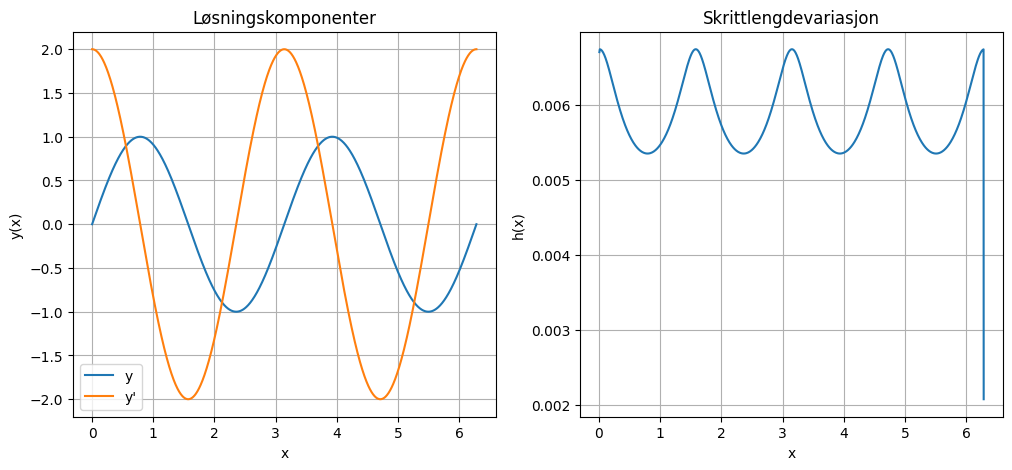

In [166]:
x0 = 0.0
y0 = np.array([0.0, 2.0])
xend = 2 * np.pi
alpha = 0.8
tol = 1e-7
h0 = 0.1
X, Y, stats = rk(x0, xend, y0, f, h0, tol,alpha)

print(stats)

plt.figure(figsize=(12, 5)) 

plt.subplot(1, 2, 1) 
plt.plot(X, Y[:, 0], label = "y")
plt.plot(X, Y[:, 1], label = "y'")
plt.title("Løsningskomponenter")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(X[1:], np.diff(X))
plt.title("Skrittlengdevariasjon")
plt.xlabel("x")
plt.ylabel("h(x)")
plt.grid()
plt.show()


$est_{n+1} = ||\vec{y}_{n+1} - \vec{z}_{n+1}||$ 

$h_{new} = \alpha * h_n * (tol / est)^{1/3}$ 

Figuren for løsningskomponentene viser hvordan funksjonene til y og y' ser ut som funksjon av x. Den periodiske utviklingen av y stemmer med y = noe og samme gjelder for y' = noe. Komponentene oppfører seg altså som forventet ut i fra differensialligningen. Kjøringen viser at det er 1070 aksepterte steg, og 1 "uakseptert" steg, avhengig av både alpha og toleranse som vises i neste oppgave. 

Plottet for skrittlengdevariasjon viser at skrittene varierer periodisk slik som y og y'. Fra formelen for $est_{n+1}$ og $h_{new}$ ser vi at skrittlengden øker når estimatet blir mindre, og minker når estimatet øker. Dette skjer med en periode på $2\pi$ som kommer fra differensialligningen. Løsningen endrer seg altså for å få et feilestimat mindre enn toleransen, og løsningen kan altså øke steglengden når estimatet er lite.

sammenlign/lag tabell med ulike alpha og tol for å se hvor mange steg man får


#### Oppgave 1d

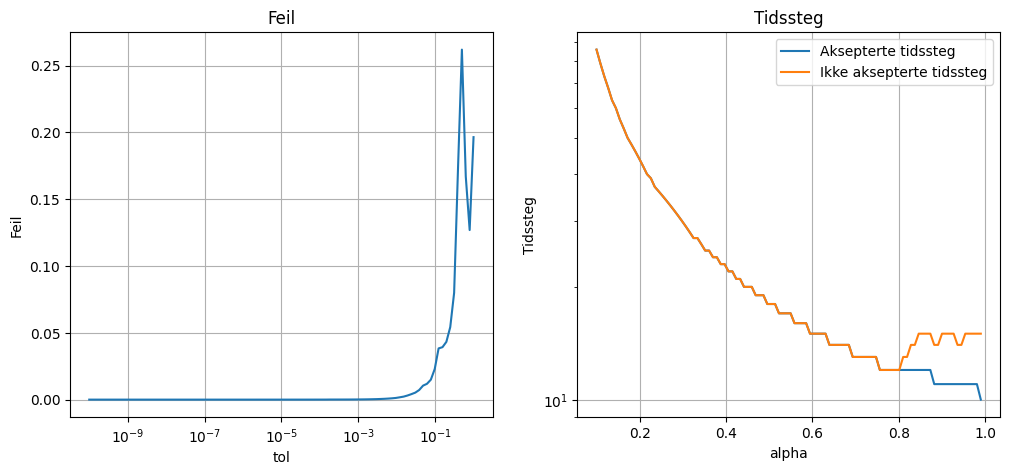

In [173]:
alphas = np.linspace(0.1, 0.99, 100)
tols = np.logspace(-10, 0, 100)
error = []
accepted = []
total = []

alpha_fixed = 0.8


for tol in tols:
    X, Y, stats_new = rk(x0, xend, y0, f, h0, tol, alpha_fixed)
    error.append(np.max(np.abs(Y[:, 0] - np.sin(2*X))))

tol_fixed = 0.1
for alpha in alphas:
    X, Y, stats_new = rk(x0, xend, y0, f, h0, tol_fixed, alpha)
    accepted.append(stats_new["Accepted steps"])
    total.append(stats_new["Discarded steps"]+stats_new["Accepted steps"])

plt.figure(figsize=(12, 5)) 

plt.subplot(1, 2, 1)
plt.plot(tols, error)
plt.title("Feil")
plt.xlabel("tol")
plt.ylabel("Feil")
plt.xscale("log")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(alphas, accepted, label="Aksepterte tidssteg")
plt.plot(alphas, total, label="Ikke aksepterte tidssteg")
plt.legend()
plt.title("Tidssteg")
plt.xlabel("alpha")
plt.ylabel("Tidssteg")
plt.yscale("log")
plt.grid()
plt.show()

Fra den første figuren ser vi at feilen øker med toleransen for begge løsningskomponentene, men feilen er fortsatt veldig liten. Økningen kan skyldes at for stor toleranse gjør funksjonen ustabil og unøyaktig. Dette plottet stemmer med antagelsen at en mindre toleranse vil gi en mer nøyaktig løsning, mens en større toleranse, her opp til 1, vil gi unøyaktige resultater med større feil. Det er derimot ikke stor forskjell i feil fra toleranse lik 1e-10 til 1e-2 som betyr at det kan brukes en relativt høy toleranse og enda få gode resultater.

Plottet av tiddsteg som variasjon av $\alpha$ viser at de aksepterte stegene blir mindre når $\alpha$ øker, mens de avslåtte tiddstegene ikke blir så mange med valgte variabelstørrelser. Dette stemmer overens med forventningene da en liten pessimistfaktor betyr at skrittlengden velges forsiktig, som fører til korte og mange steg. Når alpha øker vil skrittkengden følgelig velges mindre forsiktig, og når alpha blir stor vil veldig store skritt foreslås og deretter forkastes da de er for store. Altså er feilestimatet feil i forhold til den valgte toleransen. Her vil det da, noe som vises bedre i en kjøring med større/mindre toleranse, være flere forkastede steg, og antall totale steg har en økning som vist i plottet.

#### Oppgave 1e

In [151]:
def secant(g, z0, z1, tol):
    z_nm2 = z0
    z_nm1 = z1
    while True:
        zn = (z_nm2 * g(z_nm1) - z_nm1 * g(z_nm2)) / (g(z_nm1) - g(z_nm2))
        est = abs(z_nm1 - zn)
        if est < tol:
            break
        z_nm2 = z_nm1
        z_nm1 = zn
    return zn

z0 = 0
z1 = 0.1
tol = 1e-7

def g(z):
    return z + np.sin(z) + np.cos(z)
#Sekant
zn = secant(g, z0, z1, tol)
print(f"Rot fra sekantmetoden: {zn}") 
print(f"Setter vi inn roten for z får vi g(z) = {g(zn)}")

#Analytisk metode for å bekrefte metoden
z = sp.symbols('z')
zs = sp.nsolve(z + sp.sin(z) + sp.cos(z), 0)
print(f"Rot fra analytisk metode: {zs}")



Rot fra sekantmetoden: -0.4566247045676011
Setter vi inn roten for z får vi g(z) = 6.938893903907228e-14
Rot fra analytisk metode: -0.456624704567631


I koden er secantfunksjonen implementert for å finne roten av en funksjon g. Tester vi funksjonen av denne roten får vi et veldig lite tall omtrent 7e-14 som er omtrent null, som vil si at koden fungerer godt. Ved å bruke en numerisk løser fra sympy biblioteket ser vi at vi får en veldig lik verdi. Resultatet tyder altså på at sekantmetoden er implementert riktig.

#### Oppgave 1f

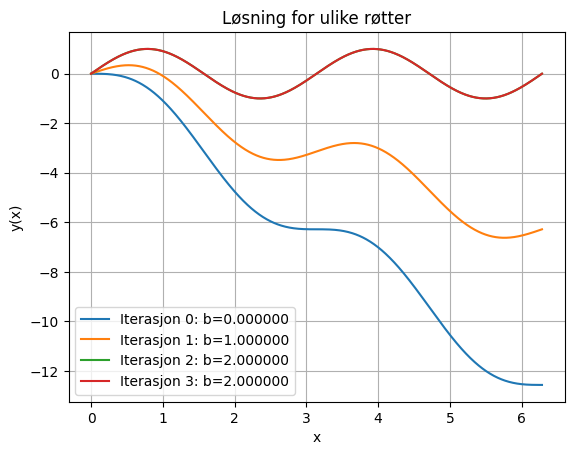

In [174]:
def secant_new(g, z0, z1, tol, max_iter=1000):
    roots = [z0, z1]
    z_nm2 = z0
    z_nm1 = z1

    for i in range(max_iter):
        zn = (z_nm2 * g(z_nm1) - z_nm1 * g(z_nm2)) / (g(z_nm1) - g(z_nm2))
        roots.append(zn)

        if abs(z_nm1 - zn) < tol:
            return roots

        z_nm2 = z_nm1
        z_nm1 = zn

    raise ValueError("Konvergerer ikke")

def bvp(b, x0, xend, f, h0, tol, alpha):
    y_init = np.array([0.0, b], dtype=float)
    X, Y, stats = rk(x0, xend, y_init, f, h0, tol, alpha)
    return Y[-1, 0]

x0 = 0.0
y0 = np.array([0.0, 1],dtype=float )
xend = 2 * np.pi
alpha = 0.8
tol = 1e-7
h0 = 0.1

g = lambda b: bvp(b, x0, xend, f, h0, tol, alpha)

b0 = 0.0
b1 = 1.0

roots = secant_new(g, b0, b1, tol, max_iter=1000)

for i, b in enumerate(roots):
    y_init = np.array([0.0, b], dtype=float)
    X, Y, stats = rk(x0, xend, y_init, f, h0, tol, alpha)
    plt.plot(X, Y[:, 0], label=f"Iterasjon {i}: b={b:.6f}")

plt.legend()
plt.title("Løsning for ulike røtter")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.grid()
plt.show()
    

Plottet viser løsningen for y når y'(xend) er ukjent for ulike iterasjoner av røttene fra sekantmetoden. Plottet viser at det tar 4 itersjoner for å nå riktig løsning, men verdiene for b som vises går raskt til riktig b=2 med b0=0 og b1=1. Dette er da en implementering av skytemeetoden der verdien av b gjetttes på frem til den treffer. Den siste løsningen som plottes ligner løsningen av y(2pi) da den har same 2pi periodiske oppførsel.  

#### Oppgave 1g

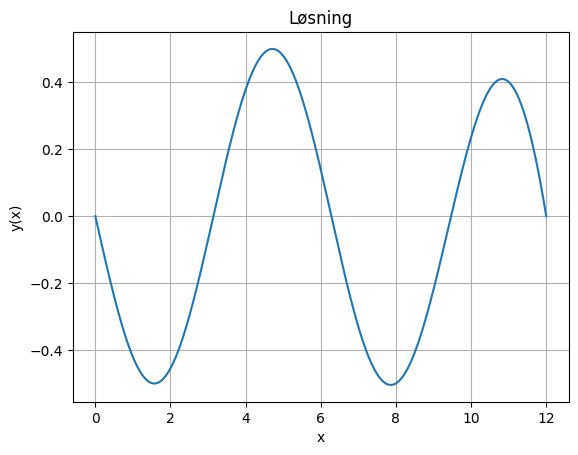

In [175]:
def f(x, y):
    return np.array([y[1], y[0] + np.sin(x)])

x0 = 0
xend = 12
y0 = np.array([0.0, 1], dtype=float)
alpha = 0.8
tol = 1e-7
h0 = 0.1

b0 = 0.0
b1 = 1.0

start_num = time.perf_counter()

g = lambda b: bvp(b, x0, xend, f, h0, tol, alpha)

roots = secant_new(g, b0, b1, tol, max_iter=1000)
y0[1] = roots[-1]
X, Y, stats = rk(x0, xend, y0, f, h0, tol, alpha)
plt.plot(X, Y[:, 0], label=f"Løsning med b = {roots[-1]:.6f}")

end_num = time.perf_counter()

plt.title("Løsning")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.grid()
plt.show()



Plottet viser løsningen av (funksjon) ved å bruke løseren fra 1c og sekantmetoden. 

#### Oppgave 1h

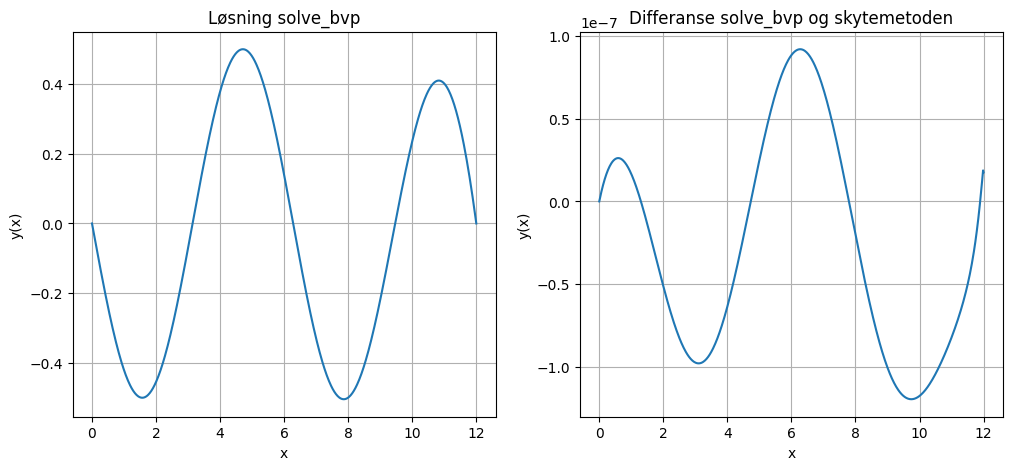

Tid 1: 0.6873 seconds
Tid 2: 0.0075 seconds


In [177]:
def fun(x,y):
    return np.vstack([y[1], y[0] + np.sin(x)])

def bc(ya, yb):
    return np.array([ya[0], yb[0]]) 


start_scipy = time.perf_counter()

x = np.copy(X)
y = np.zeros((2, x.size))

res = solve_bvp(fun, bc, x, y)

plt.figure(figsize=(12, 5)) 


plt.subplot(1,2,1)
plt.plot(res.x, res.y[0])
plt.title("Løsning solve_bvp")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.grid()
end_scipy = time.perf_counter()


plt.subplot(1,2,2)
plt.plot(x, Y[:, 0] - res.sol(x)[0] )
plt.title("Differanse solve_bvp og skytemetoden")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.grid()
plt.show()

print(f"Tid 1: {end_num - start_num:.4f} seconds")
print(f"Tid 2: {end_scipy - start_scipy:.4f} seconds")

Det første plottet viser den numeriske løsningen fra scipy med solve_bvp. Den stemmer med randbetingelsene og er periodisk og glatt slik som antatt fra differensialligningen. 
Det andre plottet viser forskjellen mellom løsningen fra skytemetoden og solve_bvp. Den skulle ideelt sett vært lik null, men varierer litt som kan skylde forskjeller i metodene. 
Etter å ha målt tiden viser scipy sin løsning seg å være mye raskere, og er dermed til å foretrekke her over skytemetoden.

## Oppgave 2

#### Oppgave 2a

In [194]:
def matrixToVector(M): # for arrays i M
    r = []
    i = []
    for row in M:
        for elem in row:
            r.append(np.real(elem))
            i.append(np.imag(elem))
    r, i = np.array(r), np.array(i)
    return np.concatenate((r,i))

def vectorToMatrix(m):  # array m
    M = []
    for i in range(2):
        row = []
        row.append(m[2*i] + m[2*i + 4]*1j)
        row.append(m[2*i + 1] + m[2*i + 5]*1j)
        M.append(row)
    return np.array(M)


In [192]:
M = [
    [1 + 2j, 3 + 4j],
    [5 + 6j, 7 + 8j],
]
print(matrixToVector(M))

m = [1,3,5,7,2,4,6,8]
print(vectorToMatrix(m))

[1. 3. 5. 7. 2. 4. 6. 8.]
[[1.+2.j 3.+4.j]
 [5.+6.j 7.+8.j]]


#### Oppgave 2b

In [195]:
def addVectors(m1, m2, m3, m4): #for arrays m1, m2, m3, m4
    v = np.concatenate((m1, m2, m3, m4))
    return v

def splitVectors(v): # for array v
    m1 = v[0:8]
    m2 = v[8:16]
    m3 = v[16:24]
    m4 = v[24:32]
    return m1, m2, m3, m4


In [193]:
m1, m2, m3, m4 = [1,2,3,4,5,6,7,8],[9,0,1,2,3,4,5,6],[7,8,9,0,1,2,3,4],[5,6,7,8,9,0,1,2]
v = [1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2]
print(addVectors(m1, m2, m3, m4))
print(splitVectors(v))

[1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 1 2]
([1, 2, 3, 4, 5, 6, 7, 8], [9, 0, 1, 2, 3, 4, 5, 6], [7, 8, 9, 0, 1, 2, 3, 4], [5, 6, 7, 8, 9, 0, 1, 2])


Her er det brukt fire vektorer m1-m4 og en vektor v sammensatt av disse til å sjekke om funksjonene klarer å sette sammen vektorer (arrays) og separere dem.

#### Oppgave 2c

In [196]:
def addMatrices(g,gt,w,wt): #for arrays gamma, gamma tilde,o mega, omega tilde
    v = addVectors(matrixToVector(g), matrixToVector(gt), matrixToVector(w), matrixToVector(wt))
    return v

def splitMatrices(v): # for array v
    vec_g, vec_gt, vec_w, vec_wt = splitVectors(v)
    g, gt, w, wt = vectorToMatrix(vec_g), vectorToMatrix(vec_gt), vectorToMatrix(vec_w), vectorToMatrix(vec_wt)
    return g, gt, w, wt

In [ ]:
#kjør koden

Hva mener oppg tekst?

#### Oppgave 2d

In [200]:
delta = 0.01
I = np.identity(2)
zeta = 3
l = 1
m = 101

def derivative(v, eps):
    g, gt, w, wt = splitMatrices(v) # gamma, gamma tilde, omega, omega tilde
    
    N = np.linalg.inv(I - g @ gt)
    Nt = np.linalg.inv(I - gt @ g)

    dx_g, dx_gt = w, wt
    dx_w = -2j * (eps + 1j*delta) * g - 2 * w @ Nt @ gt @ w
    dx_wt = -2j * (eps + 1j*delta) * gt - 2 * wt @ N @ g @ wt
    return addMatrices(dx_g, dx_gt, dx_w, dx_wt) 

hva skal returneres?

#### Oppgave 2e

In [198]:
def fun(x, vec, eps): #x(m), vec(32,m), tar inn array
    dx_vec = np.zeros_like(vec)

    for i in range(len(x)):
        col = vec[:, i]
        dx_vec[:, i] = derivative(col,eps)
   
    return dx_vec


Sjekk format

#### Oppgave 2f

In [199]:
def bc(vL, vR):
    v = np.zeros(32)

    gL, gtL, wL, wtL = splitMatrices(vL)
    gR, gtR, wR, wtR = splitMatrices(vR)

    nullVec = np.zeros_like(gL) #gL, gtL, gR, gtR = 0

    NL = np.linalg.inv(I - nullVec @ nullVec)
    NtL = np.linalg.inv(I - nullVec @ nullVec)

    NR = np.linalg.inv(I - nullVec @ nullVec)
    NtR = np.linalg.inv(I - nullVec @ nullVec)

    v1 = wL + 1/(zeta*l) * (I - gL * nullVec) * NL * (nullVec - gL) 
    v2 = wtL + 1/(zeta*l) * (I - gtL * nullVec) * NtL * (nullVec - gtL) 

    v3 = wR + 1/(zeta*l) * (I - gR * nullVec) * NR * (nullVec - gR)
    v4 = wtR + 1/(zeta*l) * (I - gtR * nullVec) * NtR * (nullVec - gtR) 

    return addMatrices(v1,v2,v3,v4) 

hva skal returneres, sjekk format

#### Oppgave 2g

In [ ]:
x = np.linspace(0,l,m)
y = np.zeros((32,m))
eps_lst = [0,1,2]

for eps in eps_lst:
    vec = 0#peiling
    res = solve_bvp(fun(x, vec, eps), bc, x, y)
    plt.plot(res.x, res.y)

plt.show()



TypeError: 'int' object is not subscriptable